<a href="https://colab.research.google.com/github/sdromigny/SOLA_4th_year_projects/blob/main/Pykonal_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pykonal
#!pip install "numpy<2.0"

In [ ]:
import numpy as np
import pykonal
import matplotlib.pyplot as plt


# --- Safety patch for NumPy >= 2.0 ---
if not hasattr(np, "infty"):
    np.infty = np.inf

# 1) Initialize solver (Cartesian coordinates)
solver = pykonal.EikonalSolver(coord_sys="cartesian")

# 2) Define grid geometry
solver.velocity.min_coords = (0.0, 0.0, 0.0)       # origin (x0, y0, z0)
solver.velocity.node_intervals = (1.0, 1.0, 1.0)   # dx, dy, dz
solver.velocity.npts = (10, 10, 10)                # nx, ny, nz

# 3) Define velocity field
nx, ny, nz = solver.velocity.npts
vel = np.empty((nx, ny, nz))

# first layer (z index = 0)
vel[:, :, 0] = 5.5
# all other layers (z = 1..9)
vel[:, :, 1:] = 5.76

solver.velocity.values = vel

# --- optional: verify ---
print("Velocity model shape:", vel.shape)
print("Top layer velocity:", vel[0,0,0])
print("Second layer velocity:", vel[0,0,1])

# 4) Define a source on the top layer
src_idx = (5, 5, 9)
solver.traveltime.values[src_idx] = 0.0
solver.unknown[src_idx] = False
solver.trial.push(*src_idx)

# 5) Solve travel times
solver.solve()

# --- optional check: travel time at some point ---
end_idx = (9, 9, 0)
tt = solver.traveltime.values[end_idx]
print(f"Travel time to node {end_idx}: {tt:.3f} s")

# --- optional: ray tracing (ensure NumPy patch above) ---
end_coord = np.array([9.0, 9.0, 0])
ray = solver.trace_ray(end_coord)
print("Ray path shape:", ray.shape)



Velocity model shape: (10, 10, 10)
Top layer velocity: 5.5
Second layer velocity: 5.76
Travel time to node (9, 9, 0): 1.940 s
Ray path shape: (43, 3)


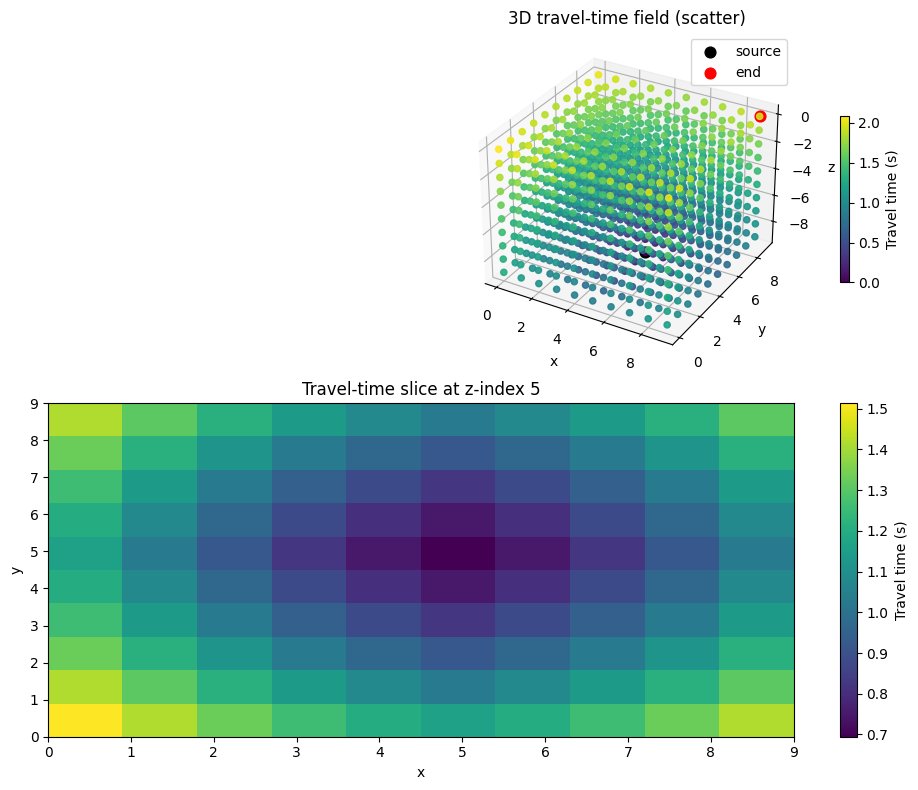

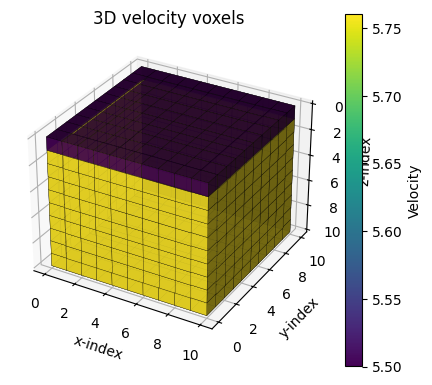

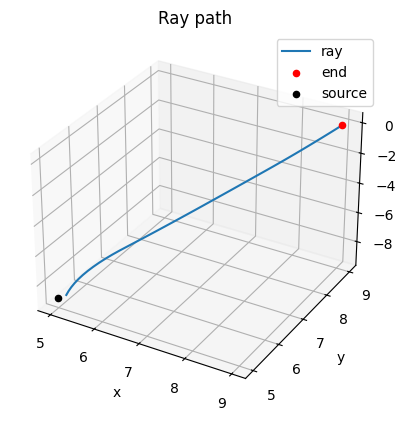

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm

# --- prepare coordinates and fields ---
min_x, min_y, min_z = solver.velocity.min_coords
dx, dy, dz = solver.velocity.node_intervals
nx, ny, nz = solver.velocity.npts

# Create coordinate arrays (grid centers at integer node indices times interval)
xs = min_x + np.arange(nx) * dx
ys = min_y + np.arange(ny) * dy
zs = min_z + np.arange(nz) * dz
X, Y, Z = np.meshgrid(xs, ys, zs, indexing='ij')  # shape (nx,ny,nz)

# Flatten for scatter plotting
coords = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))
tt_vals = solver.traveltime.values.ravel()
vel_vals = solver.velocity.values.ravel()

# ---------------------------
# 1) 3D scatter colored by travel time + 2D mid-slice of travel time
# ---------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(211, projection='3d')  # top: 3D scatter

sc = ax.scatter(coords[:, 0], coords[:, 1], -coords[:, 2],
                c=tt_vals, cmap='viridis', s=20, alpha=0.9)
ax.set_title('3D travel-time field (scatter)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

# source and endpoint markers (if available)
try:
    ax.scatter([src_coord[0]], [src_coord[1]], [-src_coord[2]], c='k', s=60, label='source')
    ax.scatter([end_coord[0]], [end_coord[1]], [-end_coord[2]], c='r', s=60, label='end')
    ax.legend()
except NameError:
    pass

# colorbar for travel time
mappable_tt = cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=tt_vals.min(), vmax=tt_vals.max()))
mappable_tt.set_array(tt_vals)
fig.colorbar(mappable_tt, ax=ax, shrink=0.5, label='Travel time (s)')

# bottom: mid-z slice (2D image) for travel time
ax2 = fig.add_subplot(212)
mid_k = nz // 2
tt_slice = solver.traveltime.values[:, :, mid_k].T  # transpose so orientation matches x-y
im = ax2.imshow(tt_slice, origin='lower',
                extent=(xs.min(), xs.max(), ys.min(), ys.max()),
                aspect='auto')
ax2.set_title(f'Travel-time slice at z-index {mid_k}')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
fig.colorbar(im, ax=ax2, label='Travel time (s)')
plt.tight_layout()
plt.show()

# ---------------------------
# 2) 3D voxel plot of velocity model + 2D mid-slice of velocity
# ---------------------------
# occupancy mask (show all voxels)
occupancy = np.ones((nx, ny, nz), dtype=bool)

# map velocities to facecolors via a cmap
vel_min, vel_max = solver.velocity.values.min(), solver.velocity.values.max()
norm_vel = plt.Normalize(vmin=vel_min, vmax=vel_max)
facecolors = cm.viridis(norm_vel(solver.velocity.values))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(121, projection='3d')
ax.set_title('3D velocity voxels')

# matplotlib voxels expects boolean occupancy and facecolors shaped (nx,ny,nz,4)
ax.voxels(occupancy, facecolors=facecolors, edgecolor='k', linewidth=0.2, alpha=0.9)
ax.set_xlabel('x-index'); ax.set_ylabel('y-index'); ax.set_zlabel('z-index')

# colorbar for velocity (create a ScalarMappable)
mappable_v = cm.ScalarMappable(cmap='viridis', norm=norm_vel)
mappable_v.set_array(solver.velocity.values)
ax.invert_zaxis()

fig.colorbar(mappable_v, ax=ax, shrink=0.6, fraction=0.05, label='Velocity')




try:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(ray[:, 0], ray[:, 1], -ray[:, 2], '-', label='ray')
    ax.scatter([end_coord[0]], [end_coord[1]], [-end_coord[2]], c='r', label='end')
    ax.scatter([src_coord[0]], [src_coord[1]], [-src_coord[2]], c='k', label='source')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z'); ax.legend()
    plt.title('Ray path')
    plt.show()
except NameError:
    pass


In [ ]:
"""
Robust ray tracing script for PyKonal.
Creates a new solver per source to avoid version-dependent reset issues.
"""

import os
import numpy as np
import pykonal
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# --- Compatibility patch for NumPy >= 2.0 (fixes PyKonal bug) ---
if not hasattr(np, "infty"):
    np.infty = np.inf

# ---------- Grid / velocity setup helper ----------
def build_solver():
    solver = pykonal.EikonalSolver(coord_sys="cartesian")

    # grid geometry
    solver.velocity.min_coords = (0.0, 0.0, 0.0)
    solver.velocity.node_intervals = (1.0, 1.0, 1.0)
    solver.velocity.npts = (10, 10, 10)

    # velocity model
    nx, ny, nz = solver.velocity.npts
    vel = np.empty((nx, ny, nz), dtype=float)
    vel[:, :, 0] = 5.5
    vel[:, :, 1:] = 5.76
    solver.velocity.values = vel

    return solver

# ---------- Utility: check point inside domain ----------
def point_inside_domain(pt, solver):
    minc = np.array(solver.velocity.min_coords, dtype=float)
    intervals = np.array(solver.velocity.node_intervals, dtype=float)
    npts = np.array(solver.velocity.npts, dtype=int)
    maxc = minc + (npts - 1) * intervals
    return np.all(pt >= minc - 1e-8) and np.all(pt <= maxc + 1e-8)

# ---------- Main tracing function (rebuild solver per source) ----------
def trace_rays(sources, receivers, out_dir="rays_output", pairwise_if_same_length=True):
    """
    For robustness across PyKonal versions we build a fresh solver for each source.
    """
    os.makedirs(out_dir, exist_ok=True)

    Ns = sources.shape[0]
    Nr = receivers.shape[0]

    if Ns == Nr and pairwise_if_same_length:
        pairs = [(i, i) for i in range(Ns)]
        info_text = f"Pairwise mode (Ns==Nr=={Ns})"
    else:
        pairs = [(i, j) for i in range(Ns) for j in range(Nr)]
        info_text = f"All-pairs mode (Ns={Ns}, Nr={Nr}, total_pairs={len(pairs)})"

    print(f"[trace_rays] {info_text}")

    all_rays = []
    failed = []

    # We'll build a prototype solver only to get domain info (min_coords, intervals, npts)
    proto = build_solver()
    min_coords = np.array(proto.velocity.min_coords)
    intervals = np.array(proto.velocity.node_intervals)
    npts = proto.velocity.npts

    for src_i, rec_j in pairs:
        src = np.asarray(sources[src_i], dtype=float)
        rec = np.asarray(receivers[rec_j], dtype=float)

        # bounds check (using prototype solver)
        if not point_inside_domain(src, proto):
            msg = f"Source {src_i} at {src} is outside domain; skipping."
            print(msg)
            failed.append(("src", src_i, rec_j, msg))
            continue
        if not point_inside_domain(rec, proto):
            msg = f"Receiver {rec_j} at {rec} is outside domain; skipping."
            print(msg)
            failed.append(("rec", src_i, rec_j, msg))
            continue

        # build fresh solver for this source
        solver = build_solver()

        # choose nearest grid node for the source
        rel = (src - min_coords) / intervals
        src_idx = tuple(np.round(rel).astype(int).tolist())
        src_idx = (
            max(0, min(npts[0] - 1, src_idx[0])),
            max(0, min(npts[1] - 1, src_idx[1])),
            max(0, min(npts[2] - 1, src_idx[2])),
        )

        # initialize source node
        try:
            solver.traveltime.values[src_idx] = 0.0
        except Exception as e:
            msg = f"Failed to set traveltime.values at {src_idx}: {e}"
            print(msg)
            failed.append(("init_tt", src_i, rec_j, msg))
            continue


        pushed = False
        try:
            # preferred approach if solver exposes 'unknown' at top-level
            solver.unknown[src_idx] = False
            try:
                solver.trial.push(*src_idx)
                pushed = True
            except Exception:
                pass
        except Exception:
            # fallback to traveltime flags
            try:
                solver.traveltime.known[src_idx] = True
                solver.traveltime.unknown[src_idx] = False
                try:
                    solver.traveltime.trial.push(*src_idx)
                    pushed = True
                except Exception:
                    pass
            except Exception:
                # last-ditch: try pushing to solver.trial if exists
                try:
                    solver.trial.push(*src_idx)
                    pushed = True
                except Exception:

                    pushed = False

        # solve the eikonal
        try:
            solver.solve()
        except Exception as e:
            msg = f"Solver failed for source {src_i} (idx={src_idx}): {e}"
            print(msg)
            failed.append(("solve", src_i, rec_j, msg))
            continue

        # trace ray from receiver back to source
        try:
            ray = solver.trace_ray(rec)
            if ray is None or len(ray) == 0:
                raise RuntimeError("trace_ray returned empty path")
        except Exception as e:
            msg = f"trace_ray failed for src {src_i} -> rec {rec_j}: {e}"
            print(msg)
            failed.append(("trace", src_i, rec_j, msg))
            continue

        # save ray
        fname = os.path.join(out_dir, f"ray_src{src_i}_rec{rec_j}.npy")
        np.save(fname, ray)
        print(f"Saved ray for src{src_i}->rec{rec_j} to {fname}; path length {len(ray)}")
        all_rays.append((src_i, rec_j, ray))

    print(f"[trace_rays] Done. rays_saved={len(all_rays)}, failures={len(failed)}")
    return all_rays, failed

# ---------- Example usage block ----------
if __name__ == "__main__":
    sources = np.load("/content/cartesian_src_SOLA.npy")      # shape (Ns,3)
    receivers = np.load("/content/cartesian_rec_SOLA.npy")  # shape (Nr,3)

    if sources.ndim != 2 or sources.shape[1] != 3:
        raise ValueError("sources.npy should be shape (Ns,3)")
    if receivers.ndim != 2 or receivers.shape[1] != 3:
        raise ValueError("receivers.npy should be shape (Nr,3)")

    rays, failures = trace_rays(sources, receivers, out_dir="rays_output")

    # plotting (same as before)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    for (s_i, r_j, ray) in rays:
        ax.plot(ray[:, 0], ray[:, 1], ray[:, 2], linewidth=1.5, label=f"s{s_i}-r{r_j}")
        ax.scatter([ray[0, 0]], [ray[0, 1]], [ray[0, 2]], marker="o", s=30)
        ax.scatter([ray[-1, 0]], [ray[-1, 1]], [ray[-1, 2]], marker="^", s=40)

    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title("Traced rays (receiver -> source)")
    if len(rays) <= 20:
        ax.legend()
    plt.tight_layout()
    plt.show()

    if failures:
        print("\nFailures:")
        for f in failures:
            print(f)


FileNotFoundError: [Errno 2] No such file or directory: '/content/cartesian_src_SOLA.npy'

In [ ]:


import os
import numpy as np
import csv
import pykonal
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---- Compatibility patch for NumPy >= 2.0 (pykonal uses np.infty in some versions) ----
if not hasattr(np, "infty"):
    np.infty = np.inf

# -------------------- Parsing utilities --------------------
def parse_dat_file(dat_path):
    """
    Parse the .dat file format you showed.
    Returns: dict mapping source_id -> list of records
    each record: {'station': str, 'tt': float, 'weight': float, 'phase': 'P'/'S'}
    """
    sources = {}
    current_source = None
    with open(dat_path, "r") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue
            if line.startswith("#"):
                # header line; take last token as source id (strip '#')
                tokens = line[1:].strip().split()
                if len(tokens) == 0:
                    continue
                current_source = tokens[-1]
                if current_source not in sources:
                    sources[current_source] = []
                continue

            # parse entry lines like: NAME   0.70   1.00  P
            parts = line.split()
            if len(parts) < 4:
                # skip malformed lines
                continue
            station = parts[0]
            try:
                tt = float(parts[1])
            except Exception:
                tt = np.nan
            try:
                weight = float(parts[2])
            except Exception:
                weight = np.nan
            phase = parts[3].upper()
            if current_source is None:
                # if file starts without header, skip
                continue
            sources[current_source].append({"station": station, "tt": tt, "weight": weight, "phase": phase})
    return sources

# -------------------- Station/source coordinate loaders --------------------
def load_station_coords_csv(station_csv):
    """
    station_csv: CSV with header: name,x,y,z  (z optional; if missing, z=0)
    Returns dict: name -> np.array([x,y,z])
    """
    coords = {}
    with open(station_csv, newline="") as csvfile:
        rdr = csv.DictReader(csvfile)
        for row in rdr:
            name = row.get("name") or row.get("station") or row.get("sta") or row.get("s")
            if name is None:
                continue
            x = float(row.get("x_m"))/1000
            y = float(row.get("y_m"))/1000
            z = float(row.get("elev"))/1000
            coords[name] = np.array([x, y, z], dtype=float)
    return coords

def load_source_coords_csv(source_csv):
    """
    source_csv: same format as station_csv; returns dict: source_id -> coord
    If you only have numeric source IDs, make a CSV mapping them to coordinates.
    """
    coords = {}
    with open(station_csv, newline="") as csvfile:
        rdr = csv.DictReader(csvfile, delimiter=' ')
        for row in rdr:
            name = row.get("name") or row.get("station") or row.get("sta") or row.get("s")
            if name is None:
                continue
            x = float(row.get("x_m"))/1000
            y = float(row.get("y_m"))/1000
            z = float(row.get("elev"))
            coords[name] = np.array([x, y, z], dtype=float)
    return coords

# -------------------- PyKonal grid builder --------------------
def build_solver_grid(min_coords=(0.0,0.0,0.0), node_intervals=(1.0,1.0,1.0), npts=(10,10,10),
                      top_layer_vel=5.5, other_vel=5.76, coord_sys="cartesian"):
    solver = pykonal.EikonalSolver(coord_sys=coord_sys)
    solver.velocity.min_coords = tuple(min_coords)
    solver.velocity.node_intervals = tuple(node_intervals)
    solver.velocity.npts = tuple(npts)
    nx, ny, nz = solver.velocity.npts
    vel = np.empty((nx, ny, nz), dtype=float)
    vel[:,:,:] = other_vel
    vel[:, :, 0] = top_layer_vel
    solver.velocity.values = vel
    return solver

def point_inside_domain(pt, solver):
    minc = np.array(solver.velocity.min_coords, dtype=float)
    intervals = np.array(solver.velocity.node_intervals, dtype=float)
    npts = np.array(solver.velocity.npts, dtype=int)
    maxc = minc + (npts - 1) * intervals
    return np.all(pt >= minc - 1e-8) and np.all(pt <= maxc + 1e-8)

# -------------------- Ray-tracing core --------------------
def trace_phase_rays(sources_dict, station_coords, source_coords,
                     phase="P", out_dir="rays_output",
                     grid_params=None):
    """
    sources_dict: output of parse_dat_file
    station_coords: dict station->coord
    source_coords: dict source_id->coord
    phase: 'P' or 'S'
    grid_params: dict with keys min_coords,node_intervals,npts,top_layer_vel,other_vel
    """
    os.makedirs(out_dir, exist_ok=True)

    # Defaults if not provided
    if grid_params is None:
        grid_params = {
            "min_coords": (0.0,0.0,0.0),
            "node_intervals": (1.0,1.0,1.0),
            "npts": (10,10,10),
            "top_layer_vel": 5.5,
            "other_vel": 5.76,
            "coord_sys": "cartesian",
        }

    # prototype solver for domain checks
    proto = build_solver_grid(min_coords=grid_params["min_coords"],
                              node_intervals=grid_params["node_intervals"],
                              npts=grid_params["npts"],
                              top_layer_vel=grid_params["top_layer_vel"],
                              other_vel=grid_params["other_vel"],
                              coord_sys=grid_params.get("coord_sys","cartesian"))
    min_coords = np.array(proto.velocity.min_coords)
    intervals = np.array(proto.velocity.node_intervals)
    npts = proto.velocity.npts

    rays_saved = []
    failures = []

    for src_id, picks in sources_dict.items():
        # filter picks by phase
        picks_phase = [p for p in picks if p["phase"] == phase]
        if len(picks_phase) == 0:
            continue

        # look up source coordinate
        if src_id not in source_coords:
            failures.append(("no_source_coord", src_id, f"Source {src_id} not in source_coords"))
            print(f"[WARN] source {src_id} has no coordinate mapping; skipping")
            continue
        src_coord = np.asarray(source_coords[src_id], dtype=float)
        if not point_inside_domain(src_coord, proto):
            failures.append(("source_outside", src_id, f"Source {src_id} outside domain"))
            print(f"[WARN] source {src_id} at {src_coord} outside solver domain; skipping")
            continue

        # build fresh solver for this source
        solver = build_solver_grid(min_coords=grid_params["min_coords"],
                              node_intervals=grid_params["node_intervals"],
                              npts=grid_params["npts"],
                              top_layer_vel=grid_params["top_layer_vel"],
                              other_vel=grid_params["other_vel"],
                              coord_sys=grid_params.get("coord_sys","cartesian"))

        # locate nearest grid node index for source
        rel = (src_coord - min_coords) / intervals
        src_idx = tuple(np.round(rel).astype(int).tolist())
        src_idx = (max(0, min(npts[0]-1, src_idx[0])),
                   max(0, min(npts[1]-1, src_idx[1])),
                   max(0, min(npts[2]-1, src_idx[2])))
        try:
            solver.traveltime.values[src_idx] = 0.0
        except Exception as e:
            failures.append(("set_tt_fail", src_id, str(e)))
            print(f"[ERROR] Failed to set traveltime at {src_idx} for source {src_id}: {e}")
            continue

        # try to push the source to trial (some PyKonal builds require it)
        try:
            solver.unknown[src_idx] = False
            solver.trial.push(*src_idx)
        except Exception:
            try:
                solver.traveltime.known[src_idx] = True
                solver.traveltime.unknown[src_idx] = False
                try:
                    solver.traveltime.trial.push(*src_idx)
                except Exception:
                    pass
            except Exception:
                # ignore and proceed; many versions are fine
                pass

        # solve eikonal
        try:
            solver.solve()
        except Exception as e:
            failures.append(("solve_fail", src_id, str(e)))
            print(f"[ERROR] solver.solve failed for source {src_id}: {e}")
            continue

        # now trace rays from receivers for this phase
        for pick in picks_phase:
            sta = pick["station"]
            if sta not in station_coords:
                failures.append(("no_sta_coord", src_id, sta))
                print(f"[WARN] station {sta} missing coords; skipping pick for source {src_id}")
                continue
            rec_coord = np.asarray(station_coords[sta], dtype=float)
            if not point_inside_domain(rec_coord, proto):
                failures.append(("rec_outside", src_id, sta))
                print(f"[WARN] receiver {sta} for source {src_id} outside domain; skipping")
                continue

            # trace: backtrace from receiver physical coordinate to the source
            try:
                ray = solver.trace_ray(rec_coord)
                if ray is None or len(ray) == 0:
                    raise RuntimeError("trace_ray returned empty")
            except Exception as e:
                failures.append(("trace_fail", src_id, sta, str(e)))
                print(f"[ERROR] trace_ray failed for src {src_id} -> rec {sta}: {e}")
                continue

            # save and record
            fname = os.path.join(out_dir, f"ray_src{src_id}_rec{sta}_{phase}.npy")
            np.save(fname, ray)
            rays_saved.append({"src": src_id, "rec": sta, "phase": phase, "file": fname, "ray": ray})
            print(f"Saved ray src={src_id} rec={sta} phase={phase} -> {fname} (path length {len(ray)})")

    return rays_saved, failures

# -------------------- Plotting helper --------------------
def plot_rays_collection(rays_saved, show=True, title=None):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection="3d")
    for rec in rays_saved:
        ray = rec["ray"]
        ax.plot(ray[:,0], ray[:,1], ray[:,2], linewidth=1.2)
        ax.scatter([ray[0,0]], [ray[0,1]], [ray[0,2]], marker="o", s=30)   # receiver (start)
        ax.scatter([ray[-1,0]], [ray[-1,1]], [ray[-1,2]], marker="^", s=40) # source (end)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    if title:
        ax.set_title(title)
    if show:
        plt.show()
    return fig, ax

# -------------------- Example main --------------------
if __name__ == "__main__":
    # paths - change to your files
    dat_file = "absolute.dat"
    station_csv = "stations.csv"       # CSV with columns: name,x,y,z
    source_csv = "sources.csv"         # CSV mapping source-id -> x,y,z

    # parse file
    sources_dict = parse_dat_file(dat_file)
    print(f"Parsed {len(sources_dict)} sources from {dat_file}")

    # load coords
    station_coords = load_station_coords_csv(station_csv)
    source_coords = load_source_coords_csv(source_csv)
    print(f"Loaded {len(station_coords)} station coords and {len(source_coords)} source coords")

    # trace P and S separately
    p_rays, p_fail = trace_phase_rays(sources_dict, station_coords, source_coords, phase="P", out_dir="rays_P")
    s_rays, s_fail = trace_phase_rays(sources_dict, station_coords, source_coords, phase="S", out_dir="rays_S")

    print("P rays saved:", len(p_rays), "P failures:", len(p_fail))
    print("S rays saved:", len(s_rays), "S failures:", len(s_fail))

    # quick plot (example)
    plot_rays_collection(p_rays, title="P-phase rays")
    plot_rays_collection(s_rays, title="S-phase rays")


In [ ]:
import numpy as np
import scipy.sparse as sp
from collections import defaultdict
from tqdm import tqdm  # optional progress bar; install with `pip install tqdm`


def _cell_index_from_point(pt, min_coords, intervals, ncx, ncy, ncz):
    """
    Return (ix,iy,iz) cell index for point pt. If point lies on the max boundary,
    clip to the last cell. Returns None if point outside domain.
    """
    rel = (pt - min_coords) / intervals
    ix = int(np.floor(rel[0]))
    iy = int(np.floor(rel[1]))
    iz = int(np.floor(rel[2]))
    if ix < 0 or ix >= ncx or iy < 0 or iy >= ncy or iz < 0 or iz >= ncz:
        return None
    return ix, iy, iz


def build_G_from_rays(rays_saved, grid_params, subdivisions=20, verbose=False):
    """
    Build sparse sensitivity matrix G for slowness-per-cell from ray paths.

    Args
    ----
    rays_saved : list of dicts
        Each dict contains at least "ray" (an Nx3 array) and optionally "phase","src","rec".
        The ordering of rays_saved defines observation index i (0..Nobs-1).
    grid_params : dict
        dict with keys: min_coords (tuple), node_intervals (tuple), npts (tuple)
        (same as used for building your solver). We interpret model cells = npts - 1.
    subdivisions : int
        Number of sub-samples per ray segment used to approximate segment-cell lengths.
        Increase for higher accuracy (cost ∝ subdivisions).
    Returns
    -------
    G : scipy.sparse.csr_matrix shape (Nobs, M)
        Sensitivity matrix where G[i,j] = path length of ray i inside cell j.
        Cell indexing uses j = ix + iy*ncx + iz*ncx*ncy (0-based).
    meta : dict
        metadata: {'Nobs', 'ncx','ncy','ncz','M','min_coords','intervals'}
    """
    min_coords = np.asarray(grid_params["min_coords"], dtype=float)
    intervals = np.asarray(grid_params["node_intervals"], dtype=float)
    npts = np.asarray(grid_params["npts"], dtype=int)
    nx, ny, nz = npts
    ncx, ncy, ncz = nx - 1, ny - 1, nz - 1
    if ncx <= 0 or ncy <= 0 or ncz <= 0:
        raise ValueError("npts must be at least 2 in each dimension to form cells")

    Nobs = len(rays_saved)
    M = ncx * ncy * ncz

    # accumulate triples lists
    row_idx = []
    col_idx = []
    data_vals = []

    it = enumerate(rays_saved)
    if verbose:
        it = tqdm(it, total=Nobs, desc="Building G")

    for i, rec in it:
        ray = np.asarray(rec["ray"], dtype=float)
        if ray.shape[0] < 2:
            # degenerate
            continue

        # For each consecutive segment, subdivide and assign samples to cells
        for a, b in zip(ray[:-1], ray[1:]):
            seg_vec = b - a
            seg_len = np.linalg.norm(seg_vec)
            if seg_len == 0:
                continue
            # sample subdivided points including left endpoint, exclude exact right endpoint
            t = np.linspace(0.0, 1.0, subdivisions, endpoint=False)
            sample_pts = a[None, :] + np.outer(t, seg_vec)  # shape (subdivisions, 3)
            # length contribution per sample
            contrib = seg_len / subdivisions
            # accumulate per cell for this segment
            counts = defaultdict(int)
            for pt in sample_pts:
                idx = _cell_index_from_point(pt, min_coords, intervals, ncx, ncy, ncz)
                if idx is None:
                    # sample outside domain -> ignore or optionally clip
                    continue
                ix, iy, iz = idx
                j = ix + iy * ncx + iz * (ncx * ncy)  # 0-based j
                counts[j] += 1
            # convert counts -> (i,j,val)
            for j, cnt in counts.items():
                row_idx.append(i)
                col_idx.append(j)
                data_vals.append(cnt * contrib)

    # build COO then convert to CSR (this will sum duplicate (i,j) entries automatically)
    if len(data_vals) == 0:
        G = sp.csr_matrix((Nobs, M), dtype=float)
    else:
        G = sp.coo_matrix((data_vals, (row_idx, col_idx)), shape=(Nobs, M)).tocsr()

    meta = {"Nobs": Nobs, "ncx": ncx, "ncy": ncy, "ncz": ncz, "M": M,
            "min_coords": min_coords.tolist(), "intervals": intervals.tolist()}

    return G, meta


def write_G_text(filename, G, one_based=True, float_fmt="{:.6e}"):
    """
    Write sparse G to text format:

    Header1: int number_of_nonzero_entries
    Header2: int N M
    Then rows: i j Gij

    Uses 1-based indexing by default (i,j start at 1). Set one_based=False for 0-based.
    """
    if not sp.isspmatrix_csr(G):
        G = G.tocsr()
    G_coo = G.tocoo()
    nnz = G_coo.nnz
    N, M = G.shape

    offset = 1 if one_based else 0
    with open(filename, "w") as f:
        f.write(f"{nnz}\n")
        f.write(f"{N} {M}\n")
        for r, c, v in zip(G_coo.row, G_coo.col, G_coo.data):
            f.write(f"{r + offset} {c + offset} {float_fmt.format(v)}\n")


def read_G_text(filename, assume_one_based=True):
    """
    Read the text format written by write_G_text. Returns csr_matrix G.
    The reader will attempt to detect 1-based vs 0-based: if the max index equals N or M,
    it will subtract 1 (i.e., interpret as 1-based). If unsure, use assume_one_based flag.
    """
    with open(filename, "r") as f:
        first = f.readline().strip()
        if not first:
            raise ValueError("Empty file")
        nnz = int(first)
        second = f.readline().strip()
        N_str, M_str = second.split()
        N = int(N_str); M = int(M_str)
        rows = []
        cols = []
        vals = []
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            i = int(parts[0])
            j = int(parts[1])
            v = float(parts[2])
            rows.append(i)
            cols.append(j)
            vals.append(v)

    # detect one-based if requested/detected
    rows = np.array(rows, dtype=int)
    cols = np.array(cols, dtype=int)
    if len(rows) == 0:
        return sp.csr_matrix((N, M), dtype=float)

    # If values appear to be 1-based (max index == N or M) then convert to 0-based
    if assume_one_based:
        rows0 = rows - 1
        cols0 = cols - 1
    else:
        # attempt to auto-detect: if max(rows) == N then probably 1-based
        if rows.max() == N or cols.max() == M:
            rows0 = rows - 1
            cols0 = cols - 1
        else:
            rows0 = rows
            cols0 = cols

    G = sp.coo_matrix((vals, (rows0, cols0)), shape=(N, M)).tocsr()
    return G
